In [12]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import DataLoader 
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd 
from sklearn.metrics import confusion_matrix 
import matplotlib.pyplot as plt 
%matplotlib inline 

In [13]:
# Convert MNIST files into a tensor of 4 Dimensions ( num of images, height, width, color channel )
transform = transforms.ToTensor()

In [14]:
# Train Data 
train_data = datasets.MNIST(root='/cnn_data', train= True, download= True, transform=transform)

In [15]:
# Test Data
test_data = datasets.MNIST(root='/cnn_data', train= False, download= True, transform=transform)

In [16]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [17]:
# create small batch size 10 
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [18]:
# Model class
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        # Fully connected layer 
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # First pass
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        # Second pass
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Re-view flatten it out 
        x = x.view(-1, 16*5*5)

        # Fully connected layer
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

In [19]:
# Create instant of a model 
torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [20]:
# Loss function optimizer 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)

In [21]:
import time 

start_time = time.time()

epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0

    for b, (X_train, y_train) in enumerate(train_loader):
        b+=1
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        predicted = torch.max(y_pred.data, 1)[1] # add up the number of correct predictions. Indexed off first point
        batch_correct = ( predicted == y_train).sum() # How there are correct from this batch, True = 1, False = 0 
        trn_corr += batch_correct

        # Update the model parameters 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        #Print some results 
        if b%600 == 0 :
            print(f'Epoch : {i} batch: {b} loss: {loss.item()}')

    train_losses.append(loss)
    train_correct.append(trn_corr)


    # Test 
    with torch.no_grad(): # No gradient so it do not update the wight and biases with the data
        for b, (X_test, y_test) in enumerate(test_loader):
            y_val =  model(X_test)
            predicted = torch.max(y_val.data, 1)[1] # adding up correct predictions 
            tst_corr += (predicted == y_test).sum()
    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)


current_time = time.time()
total_time = start_time - current_time
print(f'the training took {total_time/60} minutes')

Epoch : 0 batch: 600 loss: 0.16236087679862976
Epoch : 0 batch: 1200 loss: 0.16026683151721954
Epoch : 0 batch: 1800 loss: 0.4988675117492676
Epoch : 0 batch: 2400 loss: 0.11766686290502548
Epoch : 0 batch: 3000 loss: 0.007024545222520828
Epoch : 0 batch: 3600 loss: 0.36554718017578125
Epoch : 0 batch: 4200 loss: 0.006055619101971388
Epoch : 0 batch: 4800 loss: 0.0015429914928972721
Epoch : 0 batch: 5400 loss: 0.029892027378082275
Epoch : 0 batch: 6000 loss: 0.0003493208496365696
Epoch : 1 batch: 600 loss: 0.0030147451907396317
Epoch : 1 batch: 1200 loss: 0.1787634789943695
Epoch : 1 batch: 1800 loss: 0.0024283926468342543
Epoch : 1 batch: 2400 loss: 0.0039831167086958885
Epoch : 1 batch: 3000 loss: 0.028772804886102676
Epoch : 1 batch: 3600 loss: 0.35494497418403625
Epoch : 1 batch: 4200 loss: 0.029775962233543396
Epoch : 1 batch: 4800 loss: 0.0007359058945439756
Epoch : 1 batch: 5400 loss: 0.0009694488835521042
Epoch : 1 batch: 6000 loss: 0.5678837895393372
Epoch : 2 batch: 600 loss:

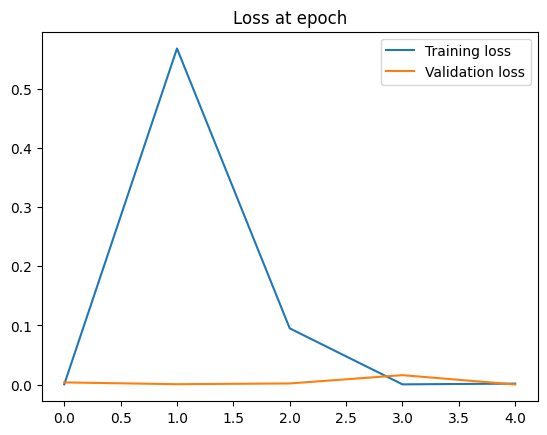

In [22]:
train_losses = [tl.item() for tl in train_losses]
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.title('Loss at epoch')
plt.legend()

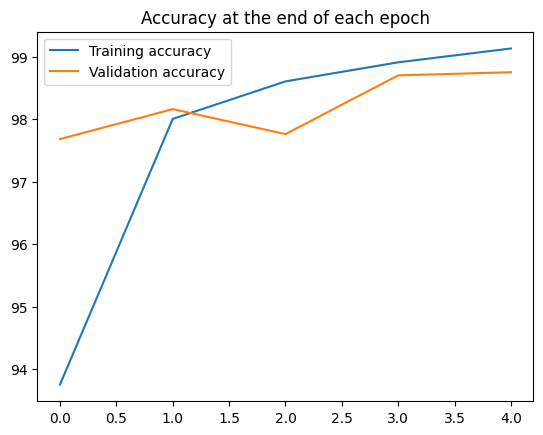

In [23]:
# graph the accuracy at the end of each epoch
plt.plot([t/600 for t in train_correct], label='Training accuracy')
plt.plot([t/100 for t in test_correct], label='Validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend()

In [24]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

In [25]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_everything:
        y_val = model(X_test)
        predicted = torch.max(y_val, 1)[1]
        correct += (predicted == y_test).sum()

In [27]:
correct.item()/len(test_data)*100

98.75

In [28]:
test_data[1111]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [29]:
test_data[1111][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

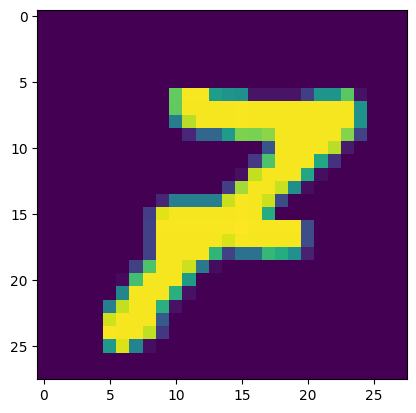

In [38]:
plt.imshow(test_data[1119][0].reshape(28,28))

In [39]:
with torch.no_grad():
    model.eval()
    new_prediction = model(test_data[1119][0].view(1,1,28,28))
new_prediction.argmax().item()



7

In [40]:
torch.save(model.state_dict(), 'MNIST_Model.pt')

In [41]:
new_model = ConvolutionalNetwork()
new_model.load_state_dict(torch.load('MNIST_Model.pt'))

<All keys matched successfully>